# Nodata management

This Jupyter notebook has been created to compare different features with several open source Python librairies for rasters management.

This notebook will particularly focus on how to handle nodata values of a raster object.

The following librairies will be considered:
- `rasterio`
- `rioxarray`
- `odc-geo`
- `geoutils`

In [1]:
import numpy as np

import rasterio
from rasterio.fill import fillnodata
from rasterio.plot import show

import rioxarray

import odc.geo.xr

import geoutils as gu

import matplotlib.pyplot as plt

In [2]:
#path to the raster object with missing values
raster_path = "../data/rasters/subset_nodata.tif"

## Nodata handling

### • rasterio

With `rasterio`, we can create numpy masked arrays to handle missing values.

When creating the array, we need to pass the argument `masked=True` when using the `.read()` method on our dataset, as follows:

In [3]:
with rasterio.open(raster_path) as src:
    arr_masked = src.read(1, masked=True)

The masked array created is actually composed of two arrays : one with the actual values (with `--` for missing data), and one with booleans.

In [4]:
arr_masked

masked_array(
  data=[[--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        ...,
        [146.0, 142.0, 144.0, ..., 21.0, 28.0, 32.0],
        [146.0, 145.0, 146.0, ..., 18.0, 28.0, 34.0],
        [--, --, --, ..., --, --, --]],
  mask=[[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [ True,  True,  True, ...,  True,  True,  True]],
  fill_value=nan,
  dtype=float32)

We can use `.mask` to access the boolean matrix (`True` if the pixel has nodata):

In [5]:
print(arr_masked.mask)

[[ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 ...
 [False False False ... False False False]
 [False False False ... False False False]
 [ True  True  True ...  True  True  True]]


And `.data` allows to check the actual values of the array (with NaNs as missing values):

In [6]:
print(arr_masked.data)

[[ nan  nan  nan ...  nan  nan  nan]
 [ nan  nan  nan ...  nan  nan  nan]
 [ nan  nan  nan ...  nan  nan  nan]
 ...
 [146. 142. 144. ...  21.  28.  32.]
 [146. 145. 146. ...  18.  28.  34.]
 [ nan  nan  nan ...  nan  nan  nan]]


### • rioxarray

Using `rioxarray`, we can convert missing values to NaNs as follows:

In [7]:
da_rxr = rioxarray.open_rasterio(raster_path)

In [8]:
da_rxr.values

array([[[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ...,
        [146., 142., 144., ...,  21.,  28.,  32.],
        [146., 145., 146., ...,  18.,  28.,  34.],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        ...,
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.]],

       [[  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        ...,
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.]],

       [[  0.,   0.,   0., ...,   0.,

We can filter missing values with `.where()`:

In [9]:
da_rxr = da_rxr.where(da_rxr != 0)

In [10]:
da_rxr.values

array([[[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ...,
        [146., 142., 144., ...,  21.,  28.,  32.],
        [146., 145., 146., ...,  18.,  28.,  34.],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ...,
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ...,
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[ nan,  nan,  nan, ...,  nan,

The second option to handle missing values is to open the raster with the argument `mask_and_scale=True` as follows:

In [11]:
da_rxr_masked = rioxarray.open_rasterio(raster_path, mask_and_scale=True)

In [12]:
da_rxr_masked.values

array([[[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ...,
        [146., 142., 144., ...,  21.,  28.,  32.],
        [146., 145., 146., ...,  18.,  28.,  34.],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        ...,
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.]],

       [[  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        ...,
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.]],

       [[  0.,   0.,   0., ...,   0.,

As we can see, this works only if the array contains nodata information stored on disk, telling rioxarray that 0 is a nodata value. Otherwise, this won't work and the nodata has to be set afterwards.

In [13]:
da_rxr_masked.rio.write_nodata(0, inplace=True)
da_rxr_masked

<xarray.DataArray (band: 4, y: 405, x: 391)> Size: 3MB
array([[[ nan,  nan, ...,  nan,  nan],
        [ nan,  nan, ...,  nan,  nan],
        ...,
        [146., 145., ...,  28.,  34.],
        [ nan,  nan, ...,  nan,  nan]],

       [[  0.,   0., ...,   0.,   0.],
        [  0.,   0., ...,   0.,   0.],
        ...,
        [  0.,   0., ...,   0.,   0.],
        [  0.,   0., ...,   0.,   0.]],

       [[  0.,   0., ...,   0.,   0.],
        [  0.,   0., ...,   0.,   0.],
        ...,
        [  0.,   0., ...,   0.,   0.],
        [  0.,   0., ...,   0.,   0.]],

       [[  0.,   0., ...,   0.,   0.],
        [  0.,   0., ...,   0.,   0.],
        ...,
        [  0.,   0., ...,   0.,   0.],
        [  0.,   0., ...,   0.,   0.]]], shape=(4, 405, 391), dtype=float32)
Coordinates:
  * band         (band) int64 32B 1 2 3 4
  * x            (x) float64 3kB 4.299e+05 4.299e+05 ... 4.3e+05 4.3e+05
  * y            (y) float64 3kB 7.08e+06 7.08e+06 ... 7.08e+06 7.08e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    _FillValue:     0.0

### • odc-geo

`odc-geo` allows conversion to float + NaNs.

In [14]:
ds_odcgeo = rioxarray.open_rasterio(raster_path)

As we are working with an `xarray` structure, we can mimic what we did with `rioxarray` and use `.where()` to filter the missing values by NaN:

In [15]:
ds_odcgeo = ds_odcgeo.where(ds_odcgeo != 0)
ds_odcgeo

<xarray.DataArray (band: 4, y: 405, x: 391)> Size: 3MB
array([[[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ...,
        [146., 142., 144., ...,  21.,  28.,  32.],
        [146., 145., 146., ...,  18.,  28.,  34.],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ...,
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ...,
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ...,
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]]],
      shape=(4, 405, 391), dtype=float32)
Coordinates:
  * band         (band) int64 32B 1 2 3 4
  * x            (x) float64 3kB 4.299e+05 4.299e+05 ... 4.3e+05 4.3e+05
  * y            (y) float64 3kB 7.08e+06 7.08e+06 ... 7.08e+06 7.08e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    _FillValue:     nan
    scale_factor:   1.0
    add_offset:     0.0

In [16]:
ds_odcgeo.data

array([[[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ...,
        [146., 142., 144., ...,  21.,  28.,  32.],
        [146., 145., 146., ...,  18.,  28.,  34.],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ...,
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ...,
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[ nan,  nan,  nan, ...,  nan,

### • geoutils

`geoutils` has a function [`set_nodata()`](https://geoutils.readthedocs.io/en/stable/gen_modules/geoutils.Raster.set_nodata.html#geoutils.Raster.set_nodata) to handle missing values.

This function will set a new nodata value for all bands.

In [17]:
gu_rast = gu.Raster(raster_path)

In [18]:
gu_rast

Raster(
  data=not_loaded; shape on disk (4, 405, 391); will load (4, 405, 391)
  transform=| 0.31, 0.00, 429906.92|
            | 0.00,-0.31, 7080212.71|
            | 0.00, 0.00, 1.00|
  crs=EPSG:32627
  nodata=nan)

In [19]:
gu_rast.nodata

nan

`geoutils` both manages masked arrays and NaNs.

By default, when instantiating the Raster, the object is "lazy", meaning that it is not yet loaded into memory. However when accessing the array with `.data` it will load the data in memory.

If using `.data` to access values, it will return a masked array (with `--` to symbolize nodata values):

In [20]:
gu_rast.data

masked_array(
  data=[[[--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         ...,
         [146.0, 142.0, 144.0, ..., 21.0, 28.0, 32.0],
         [146.0, 145.0, 146.0, ..., 18.0, 28.0, 34.0],
         [--, --, --, ..., --, --, --]],

        [[0.0, 0.0, 0.0, ..., 0.0, 0.0, 0.0],
         [0.0, 0.0, 0.0, ..., 0.0, 0.0, 0.0],
         [0.0, 0.0, 0.0, ..., 0.0, 0.0, 0.0],
         ...,
         [0.0, 0.0, 0.0, ..., 0.0, 0.0, 0.0],
         [0.0, 0.0, 0.0, ..., 0.0, 0.0, 0.0],
         [0.0, 0.0, 0.0, ..., 0.0, 0.0, 0.0]],

        [[0.0, 0.0, 0.0, ..., 0.0, 0.0, 0.0],
         [0.0, 0.0, 0.0, ..., 0.0, 0.0, 0.0],
         [0.0, 0.0, 0.0, ..., 0.0, 0.0, 0.0],
         ...,
         [0.0, 0.0, 0.0, ..., 0.0, 0.0, 0.0],
         [0.0, 0.0, 0.0, ..., 0.0, 0.0, 0.0],
         [0.0, 0.0, 0.0, ..., 0.0, 0.0, 0.0]],

        [[0.0, 0.0, 0.0, ..., 0.0, 0.0, 0.0],
         [0.0, 0.0, 0.0, ..., 0.0, 0.0, 0.0],
         [0.0, 0.0, 0.0,

Using `.data.mask` will return the boolean mask of the precedent array, with `True` where data is masked and `False` where data is valid:

In [21]:
gu_rast.data.mask

array([[[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [ True,  True,  True, ...,  True,  True,  True]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, Fal

`geoutils` can also handle nan for nodata values, [`.get_nanarray()`](https://geoutils.readthedocs.io/en/stable/gen_modules/geoutils.Raster.get_nanarray.html#geoutils.Raster.get_nanarray) will return a numpy array with NaNs:

In [22]:
gu_rast.get_nanarray()

array([[[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ...,
        [146., 142., 144., ...,  21.,  28.,  32.],
        [146., 145., 146., ...,  18.,  28.,  34.],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        ...,
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.]],

       [[  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        ...,
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.]],

       [[  0.,   0.,   0., ...,   0.,

## NaNs VS Masked Arrays

- NaNs

Working with NaN values has several advantages, they are easily handled by most librairies (`pandas`, `xarray`...). They are very useful for fast data manipulation (i.e. `np.isnan()` to return a boolean matrix), and they have a compact format (a single array, no separate mask structure). However working with NaNs with can be a bit tricky, as the data is forced to be casted to float (NaNs are float for `numpy`) even if the input raster uses integers, which can lead to performance or storage issues. This is mitigated by lazy behaviors.
<br>
<br>

- Masked Arrays

On the opposite, masked arrays are ideal when we don't want to convert data to float, they work well with integers, unlike NaNs. There is also a clear distinction between the "actual value" and the "mask", whereas NaNs can sometimes be confusing (NaN = nodata or NaN = invalid result ?). On the other hand, masked arrays have a more complex structure than a simple NaN array, less universal and require more storage space than NaNs. Moreover, numpy support of masked arrays is not complete, some functions are missing or less optimized with respect to the default API.

## Nodata interpolation

Nodata interpolation is only available in `rasterio` and `rioxarray` librairies.

This method is used to fill gaps where data is missing, to produce cleaner visualizations. Different methods can be used to perform the interpolation : linear, nearest, cubic...

In this example we will work on a raster image that has several missing rows.

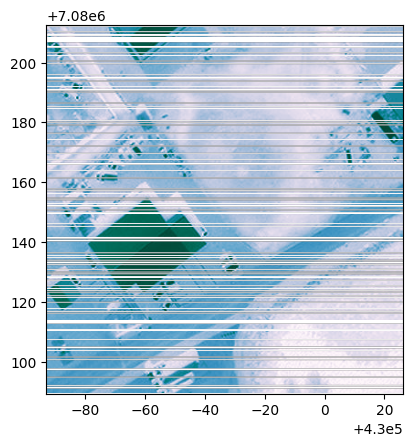

In [23]:
with rasterio.open(raster_path) as src:
    show(src, cmap="PuBuGn")

### • rasterio

With rasterio, we will use the [`.fillnodata()`](https://rasterio.readthedocs.io/en/latest/api/rasterio.fill.html) function to perform the interpolation.

This function will search for all nodata values of our dataset and use an algorithm to "fill holes" by using the values of valid neighbour pixels.

In [24]:
ds_rasterio = rasterio.open(raster_path)
    
b1 = ds_rasterio.read(1) #first band

Here we can see that our dataset has several NaN values :

In [25]:
b1

array([[ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       ...,
       [146., 142., 144., ...,  21.,  28.,  32.],
       [146., 145., 146., ...,  18.,  28.,  34.],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan]],
      shape=(405, 391), dtype=float32)

If we try to use the `fillnodata` function directly, we get an error message, rasterio is asking for a mask for where to apply the interpolation:

In [26]:
ds_nodata_interp = fillnodata(b1)

ValueError: An mask array is required

So we will create a mask containing all the nodata values with `np.isnan()`:

In [31]:
mask_nodata = np.isnan(b1)

It will create a boolean array, True if the pixel has no data and False the opposite.

In [33]:
mask_nodata

array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [ True,  True,  True, ...,  True,  True,  True]], shape=(405, 391))

`rasterio` will try to interpolate all pixels with the value 0 (or False). Since in our case we have the opposite (missing values marked as True (or 1)), we need to reverse our array with the function `np.invert()` (or directly with `~`):

In [34]:
mask_nodata = np.invert(mask_nodata)

In [35]:
mask_nodata

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [False, False, False, ..., False, False, False]], shape=(405, 391))

Our mask is now ready to be used with the `.fillnodata()` function:

In [36]:
ds_nodata_interp = fillnodata(b1, mask=mask_nodata)

If we check our new array, NaN values have been correctly interpolated:

In [37]:
ds_nodata_interp

array([[ 40.671173,  36.920998,  52.170826, ...,  97.51317 ,  97.      ,
         97.      ],
       [ 40.862232,  36.832817,  51.8034  , ...,  97.52786 ,  97.      ,
         97.      ],
       [ 41.615223,  36.485283,  50.35534 , ...,  97.585785,  97.      ,
         97.      ],
       ...,
       [146.      , 142.      , 144.      , ...,  21.      ,  28.      ,
         32.      ],
       [146.      , 145.      , 146.      , ...,  18.      ,  28.      ,
         34.      ],
       [145.58578 , 145.41422 , 146.82843 , ...,  22.142136,  30.485281,
         34.      ]], shape=(405, 391), dtype=float32)

And looking at the map, missing data have been well replaced:

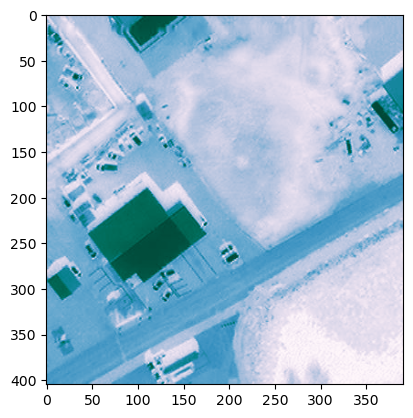

In [43]:
plt.imshow(ds_nodata_interp, cmap="PuBuGn")
plt.show()

### • rioxarray

With rioxarray, we will use the [`interpolate_na()`](https://corteva.github.io/rioxarray/stable/rioxarray.html#rioxarray.raster_array.RasterArray.interpolate_na) method to perform nodata interpolation.

In [44]:
da_rxr = rioxarray.open_rasterio(raster_path)

Once again, we can look at our map with missing data:

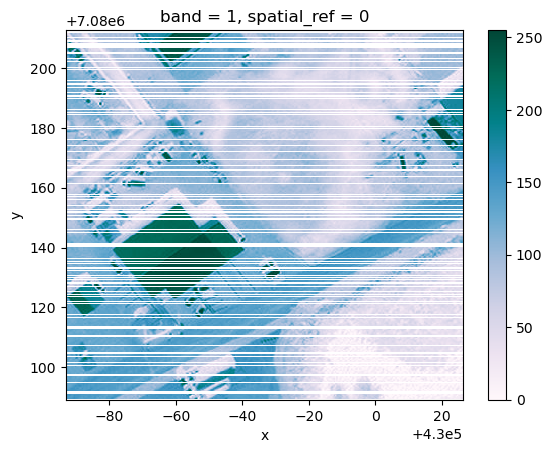

In [46]:
da_rxr.sel(band=1).plot(cmap="PuBuGn")
plt.show()

And check the actual values of our array:

In [48]:
da_rxr.values

array([[[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ...,
        [146., 142., 144., ...,  21.,  28.,  32.],
        [146., 145., 146., ...,  18.,  28.,  34.],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        ...,
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.]],

       [[  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        ...,
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.]],

       [[  0.,   0.,   0., ...,   0.,

With `rioxarray`, this time we don't explicitly need to specify the mask on where to apply the interpolation.

As an argument (optional), we can specify the interpolation method ("linear", "nearest" (by default) or "cubic"), if we want to.

In [49]:
rxr_interp = da_rxr.rio.interpolate_na(method="linear")

Checking our new array, we can see that missing values have been interpolated:

In [50]:
rxr_interp.values

array([[[ 47.,  34.,  40., ...,  98.,  97.,  97.],
        [ 47.,  34.,  40., ...,  98.,  97.,  97.],
        [ 47.,  34.,  40., ...,  98.,  97.,  97.],
        ...,
        [146., 142., 144., ...,  21.,  28.,  32.],
        [146., 145., 146., ...,  18.,  28.,  34.],
        [146., 145., 146., ...,  18.,  28.,  34.]],

       [[  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        ...,
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.]],

       [[  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        ...,
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.],
        [  0.,   0.,   0., ...,   0.,   0.,   0.]],

       [[  0.,   0.,   0., ...,   0.,

We can plot our new raster as well:

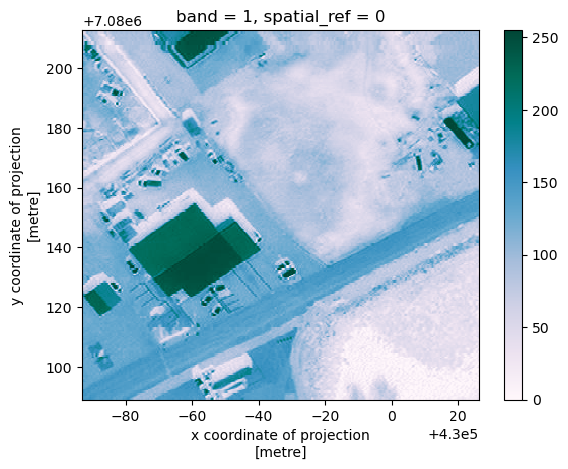

In [51]:
rxr_interp.sel(band=1).plot(cmap="PuBuGn")
plt.show()

We can finally compare the nodata interpolation results between `rasterio` and `rioxarray`. We can see the methods are not exactly the same:

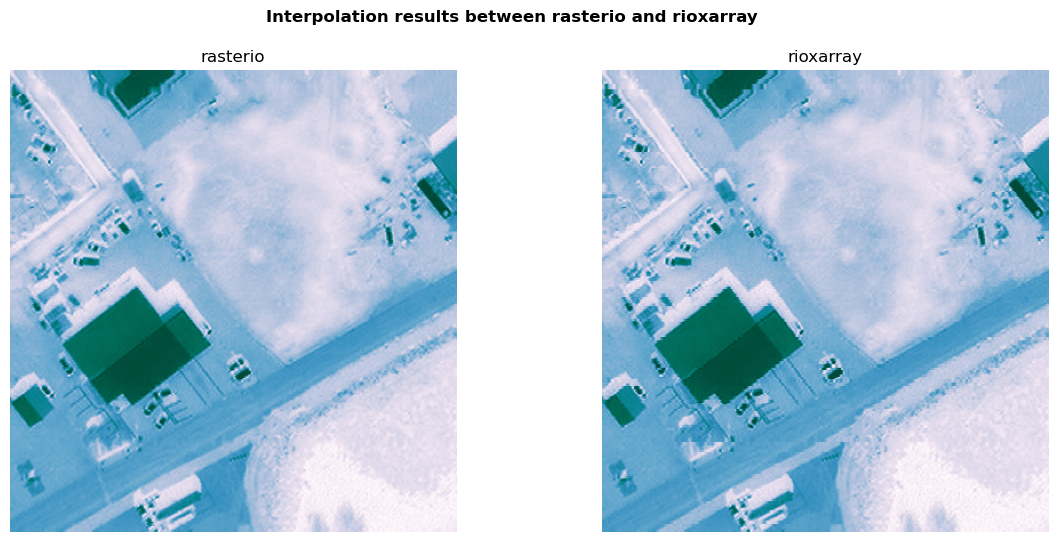

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

fig.suptitle("Interpolation results between rasterio and rioxarray", fontweight="bold")

#rasterio interp
axes[0].imshow(ds_nodata_interp, cmap="PuBuGn")
axes[0].set_title("rasterio")
axes[0].axis("off")

#rioxarray interp
axes[1].imshow(rxr_interp.sel(band=1), cmap="PuBuGn")
axes[1].set_title("rioxarray")
axes[1].axis("off")

plt.show()